In [1]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_cn7
from common.train_test_split import split_data
from common.model_composition import model_composition

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
train_cn7 = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_cn7.csv")

In [3]:
X_cn7, y_cn7 = preprocessing_cn7(train_cn7)

print("X shape:", X_cn7.shape)
print("y shape:", y_cn7.shape)

X shape: (1211, 23)
y shape: (1211,)


In [4]:
X_cn7_all = X_cn7.copy()

# 시간 관련
X_cn7_all["Injection_minus_Filling"] = (
    X_cn7_all["Injection_Time"] - X_cn7_all["Filling_Time"]
)

X_cn7_all["Process_Time_Sum"] = (
    X_cn7_all["Injection_Time"]
    + X_cn7_all["Filling_Time"]
    + X_cn7_all["Plasticizing_Time"]
    + X_cn7_all["Cycle_Time"]
    + X_cn7_all["Clamp_Close_Time"]
)

X_cn7_all["Cycle_minus_Plasticizing"] = (
    X_cn7_all["Cycle_Time"] - X_cn7_all["Plasticizing_Time"]
)

X_cn7_all["Cycle_minus_Injection"] = (
    X_cn7_all["Cycle_Time"] - X_cn7_all["Injection_Time"]
)

X_cn7_all["Cycle_minus_Filling"] = (
    X_cn7_all["Cycle_Time"] - X_cn7_all["Filling_Time"]
)

X_cn7_all["Plasticizing_minus_Filling"] = (
    X_cn7_all["Plasticizing_Time"] - X_cn7_all["Filling_Time"]
)

# RPM 관련
X_cn7_all["Screw_RPM_Gap"] = (
    X_cn7_all["Max_Screw_RPM"] - X_cn7_all["Average_Screw_RPM"]
)

X_cn7_all["Screw_RPM_Mean"] = (
    X_cn7_all["Max_Screw_RPM"] + X_cn7_all["Average_Screw_RPM"]
) / 2

# 온도 관련
barrel_cols = [
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6"
]

X_cn7_all["Barrel_Temp_Range"] = (
    X_cn7_all[barrel_cols].max(axis=1)
    - X_cn7_all[barrel_cols].min(axis=1)
)

X_cn7_all["Barrel_Temp_Mean"] = (
    X_cn7_all[barrel_cols].mean(axis=1)
)

X_cn7_all["Barrel_Temp_Std"] = (
    X_cn7_all[barrel_cols].std(axis=1)
)

# 전체 공정 편차 관련
X_cn7_all["Mean_Abs_Deviation"] = (
    X_cn7.abs().mean(axis=1)
)

X_cn7_all["Max_Abs_Deviation"] = (
    X_cn7.abs().max(axis=1)
)

X_cn7_all["Deviation_Count_2Sigma"] = (
    (X_cn7.abs() > 2).sum(axis=1)
)

X_cn7_all["Deviation_Count_3Sigma"] = (
    (X_cn7.abs() > 3).sum(axis=1)
)

print("기존 변수 수:", X_cn7.shape[1])
print("전체 변수 수:", X_cn7_all.shape[1])
print("추가 파생변수 수:", X_cn7_all.shape[1] - X_cn7.shape[1])

기존 변수 수: 23
전체 변수 수: 38
추가 파생변수 수: 15


In [5]:
X_train_cn7_all, X_test_cn7_all, y_train_cn7_all, y_test_cn7_all = split_data(
    X_cn7_all,
    y_cn7
)

model_composition(
    X_train_cn7_all,
    X_test_cn7_all,
    y_train_cn7_all,
    y_test_cn7_all
)

[LightGBM] [Info] Number of positive: 14, number of negative: 954
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2169
[LightGBM] [Info] Number of data points in the train set: 968, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014463 -> initscore=-4.221606
[LightGBM] [Info] Start training from score -4.221606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,Pred Normal,Pred Defect
Actual Normal,240,0
Actual Defect,3,0



[Random Forest]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.06142167011732229

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0



[LightGBM]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.13999999999999999

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0



[XGBoost]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.10352728047740836

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0



[CatBoost]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.154985754985755

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0


### Lightgbm으로 shap


c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


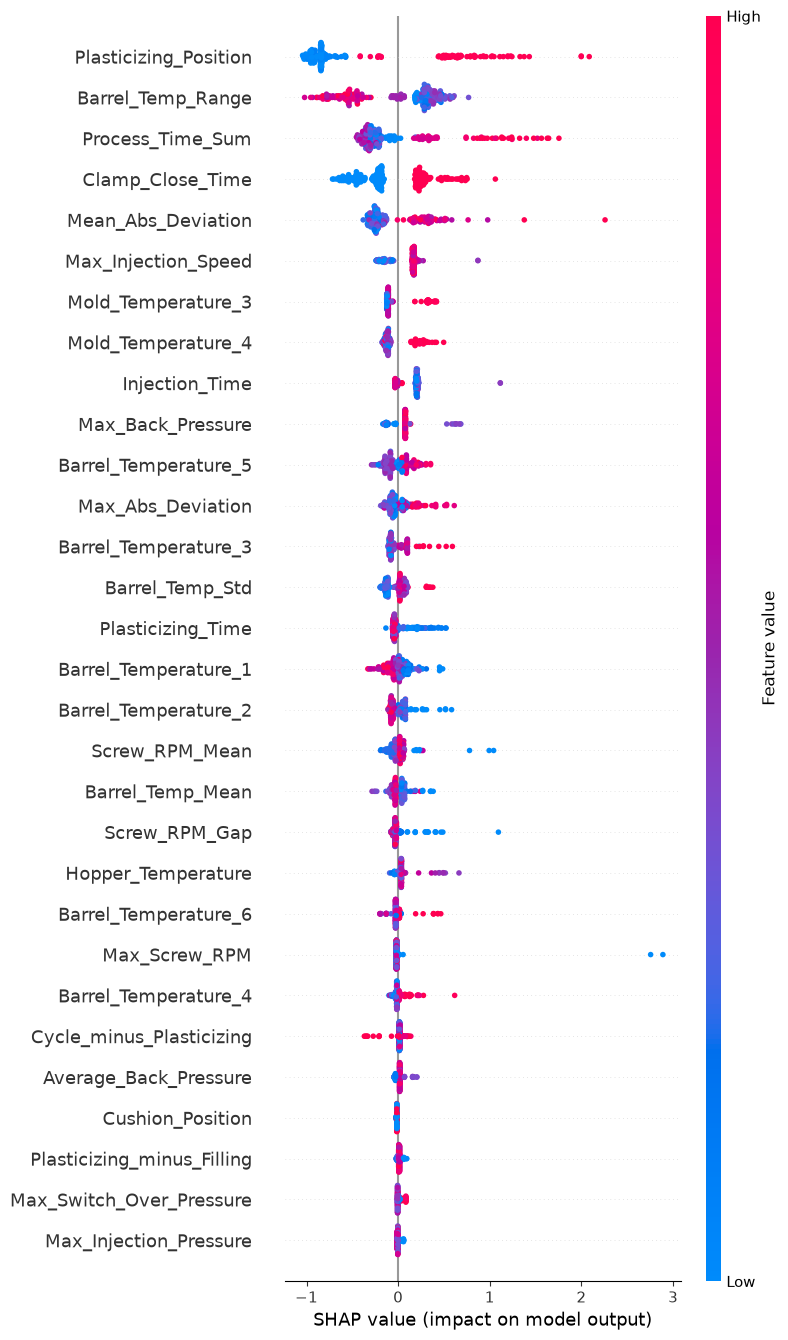

In [7]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

model_shap = LGBMClassifier(
    random_state=42,
    verbose=-1
)

model_shap.fit(
    X_train_cn7_all,
    y_train_cn7_all
)

explainer = shap.TreeExplainer(model_shap)

shap_values = explainer.shap_values(X_test_cn7_all)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_cn7_all,
    max_display=30
)

In [8]:
X_cn7_shap3 = X_cn7.copy()

# 1. Barrel_Temp_Range
barrel_cols = [
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6"
]

X_cn7_shap3["Barrel_Temp_Range"] = (
    X_cn7_shap3[barrel_cols].max(axis=1)
    - X_cn7_shap3[barrel_cols].min(axis=1)
)

# 2. Process_Time_Sum
X_cn7_shap3["Process_Time_Sum"] = (
    X_cn7_shap3["Injection_Time"]
    + X_cn7_shap3["Filling_Time"]
    + X_cn7_shap3["Plasticizing_Time"]
    + X_cn7_shap3["Cycle_Time"]
    + X_cn7_shap3["Clamp_Close_Time"]
)

# 3. Mean_Abs_Deviation
# 파생변수가 포함되지 않은 원본 X_cn7 기준
X_cn7_shap3["Mean_Abs_Deviation"] = (
    X_cn7.abs().mean(axis=1)
)

X_train_cn7_shap3, X_test_cn7_shap3, y_train_cn7_shap3, y_test_cn7_shap3 = split_data(
    X_cn7_shap3,
    y_cn7
)

model_composition(
    X_train_cn7_shap3,
    X_test_cn7_shap3,
    y_train_cn7_shap3,
    y_test_cn7_shap3
)


[Logistic Regression]
Accuracy : 0.9876543209876543
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.21944444444444444

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,240,0
Actual Defect,3,0



[Random Forest]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.040177604505089885

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0



[LightGBM]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.12633689839572193

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0



[XGBoost]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.09949723479135245

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0



[CatBoost]
Accuracy : 0.9835390946502057
Precision: 0.0
Recall   : 0.0
F1       : 0.0
PR-AUC   : 0.1392857142857143

Confusion Matrix


,Pred Normal,Pred Defect
Actual Normal,239,1
Actual Defect,3,0
